## Generation Comparison

In [ ]:
# setup

import sys
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

from data import build_vocab, encode
from rnn import VanillaRNN
from lstm import LSTMModel

device = torch.device("cpu")

PROCESSED_DATA_DIR = Path.cwd().parent / "data" / "processed"
CHECKPOINT_DIR     = Path.cwd().parent / "checkpoints"
RESULTS_DIR        = Path.cwd().parent / "results" / "generated_samples"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with open(PROCESSED_DATA_DIR / "corpus_clean.txt", "r", encoding="utf-8") as f:
    text = f.read()

train_text = text[:738058]
char2idx, idx2char = build_vocab(train_text, min_count=10)
vocab_size = len(idx2char)

print(f"Vocab size: {vocab_size}")

Vocab size: 71


In [2]:
# loading trained models

rnn_model = VanillaRNN(vocab_size=vocab_size, embed_dim=64, hidden_size=256)
rnn_checkpoint = torch.load(CHECKPOINT_DIR / "rnn_best.pt", map_location=device)
rnn_model.load_state_dict(rnn_checkpoint["model_state_dict"])
rnn_model.to(device)
rnn_model.eval()

lstm_model = LSTMModel(vocab_size=vocab_size, embed_dim=64, hidden_size=256)
lstm_checkpoint = torch.load(CHECKPOINT_DIR / "lstm_best.pt", map_location=device)
lstm_model.load_state_dict(lstm_checkpoint["model_state_dict"])
lstm_model.to(device)
lstm_model.eval()

print(f"RNN  loaded — val loss: {rnn_checkpoint['val_loss']:.4f}")
print(f"LSTM loaded — val loss: {lstm_checkpoint['val_loss']:.4f}")

RNN  loaded — val loss: 1.4449
LSTM loaded — val loss: 1.4327


In [3]:
# temperature sampling function

def generate(model, seed_text, char2idx, idx2char, num_chars=500,
             temperature=1.0, model_type="rnn"):

    model.eval()
    generated = seed_text

    unk_idx = char2idx["<UNK>"]
    seed_encoded = [char2idx.get(ch, unk_idx) for ch in seed_text]

    if model_type == "rnn":
        h = model.init_hidden(1, device)
    else:
        h, c = model.init_hidden(1, device)

    with torch.no_grad():
  
        for idx in seed_encoded:
            x = torch.tensor([[idx]], dtype=torch.long, device=device)
            if model_type == "rnn":
                logits, h, _ = model(x, h)
            else:
                logits, h, c, _ = model(x, h, c)

    
        input_idx = seed_encoded[-1]

        for _ in range(num_chars):
            x = torch.tensor([[input_idx]], dtype=torch.long, device=device)

            if model_type == "rnn":
                logits, h, _ = model(x, h)
            else:
                logits, h, c, _ = model(x, h, c)

            logits = logits.squeeze()

            scaled_logits = logits / temperature
            probs = F.softmax(scaled_logits, dim=-1)

            next_idx = torch.multinomial(probs, num_samples=1).item()

            generated += idx2char[next_idx]
            input_idx = next_idx

    return generated

In [4]:
# generating text at four temperatures

SEED        = "Raskolnikov"
NUM_CHARS   = 500
TEMPERATURES = [0.5, 0.8, 1.0, 1.2]

rnn_samples  = {}
lstm_samples = {}

for temp in TEMPERATURES:
    print(f"\n{'='*60}")
    print(f"Temperature: {temp}")
    print(f"{'='*60}")

    rnn_text = generate(rnn_model, SEED, char2idx, idx2char,
                        num_chars=NUM_CHARS, temperature=temp,
                        model_type="rnn")
    lstm_text = generate(lstm_model, SEED, char2idx, idx2char,
                         num_chars=NUM_CHARS, temperature=temp,
                         model_type="lstm")

    rnn_samples[temp]  = rnn_text
    lstm_samples[temp] = lstm_text

    print(f"\n--- RNN (T={temp}) ---")
    print(rnn_text)
    print(f"\n--- LSTM (T={temp}) ---")
    print(lstm_text)


Temperature: 0.5

--- RNN (T=0.5) ---
Raskolnikover and you was a man easily.

“Let me to the same before his hair and impities. It was the face of his mind, still and ready to be in his painter and the best to be still and reading and relations the best boother and his hands in a man and still blanding the old woman of your nquestion and the chief that he is not the
sound to himself, and he had been to the student. There was a long away. This was sat down on the street and was not an the crime of the white and the day do you go to him as the 

--- LSTM (T=0.5) ---
Raskolnikovankands. And she was all the old woman was more in a minure in his recodger to him.

“What’s the conversation of the chairs of his hand and strefted the noticed his first points and face at the sofa, but in the stairst and shame and
all the flashed with the thirty of his better down. He knew and went on a great desiless and the corner and stood and seemed to his hands, and and for the street. Simply in the standi

In [5]:
# saving all generated samples

output_path = RESULTS_DIR / "generated_samples.txt"

with open(output_path, "w", encoding="utf-8") as f:
    f.write("Generated Samples — Remembering Raskolnikov\n")
    f.write("RNN vs LSTM Character-Level Text Generation\n")
    f.write("Seed: 'Raskolnikov'\n")
    f.write("=" * 60 + "\n\n")

    for temp in TEMPERATURES:
        f.write(f"TEMPERATURE: {temp}\n")
        f.write("-" * 60 + "\n\n")
        f.write(f"RNN (T={temp}):\n")
        f.write(rnn_samples[temp] + "\n\n")
        f.write(f"LSTM (T={temp}):\n")
        f.write(lstm_samples[temp] + "\n\n")
        f.write("=" * 60 + "\n\n")

print(f"Saved to {output_path}")

Saved to c:\Users\NASA2004\OneDrive\Documents\rnn-lstm-long-range-memory\results\generated_samples\generated_samples.txt


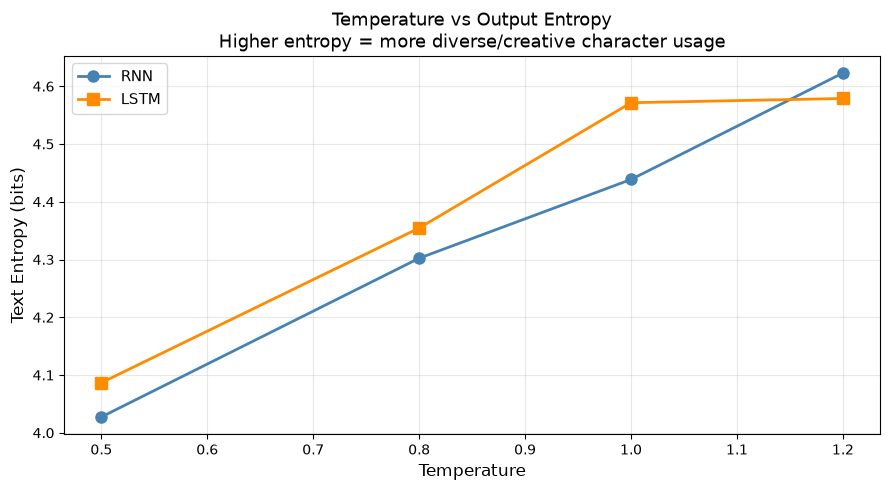

Saved to results/figures/temperature_entropy.png


In [6]:
# visualizing the temperature effect

def text_entropy(text):

    from collections import Counter
    counts = Counter(text)
    total  = len(text)
    probs  = np.array([c/total for c in counts.values()])
    # shannon entropy
    return -np.sum(probs * np.log2(probs + 1e-10))

rnn_entropies  = [text_entropy(rnn_samples[t])  for t in TEMPERATURES]
lstm_entropies = [text_entropy(lstm_samples[t]) for t in TEMPERATURES]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(TEMPERATURES, rnn_entropies,  marker="o", color="steelblue",
        label="RNN",  linewidth=2, markersize=8)
ax.plot(TEMPERATURES, lstm_entropies, marker="s", color="darkorange",
        label="LSTM", linewidth=2, markersize=8)

ax.set_xlabel("Temperature", fontsize=12)
ax.set_ylabel("Text Entropy (bits)", fontsize=12)
ax.set_title("Temperature vs Output Entropy\n"
             "Higher entropy = more diverse/creative character usage",
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()

FIGURES_DIR = Path.cwd().parent / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / "temperature_entropy.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved to results/figures/temperature_entropy.png")